In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

energy_sector = pd.read_csv('energy_sector_prepared.csv', index_col=0, parse_dates=True)

# Calculate daily return of the asset for backtesting (if not already there)
energy_sector['daily_return'] = energy_sector.iloc[:, 0].pct_change()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Agnib\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [66]:
df_financial = pd.read_csv('Financial.csv')

# Extract hidden YYYY-MM-DD dates from the text
def extract_date(text):
    match = re.search(r'(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})', str(text))
    if match: return match.group(1)[:10] 
    return None

df_financial['Date'] = df_financial['Content'].apply(extract_date)
df_financial['Date'] = pd.to_datetime(df_financial['Date'], errors='coerce')
df_financial = df_financial.dropna(subset=['Date'])

# Filter for Energy Sector keywords
energy_keywords = ['oil', 'energy', 'opec', 'crude', 'exxon', 'chevron', 'gasoline']
pattern = '|'.join(energy_keywords)
energy_news = df_financial[df_financial['Content'].str.lower().str.contains(pattern, na=False)].copy()

# Rename and format
energy_news = energy_news.rename(columns={'Content': 'Text'})
clean_news = energy_news[['Date', 'Text']].sort_values('Date').reset_index(drop=True)
headline_count = clean_news['Text'].str.len().sum()
print(f"Total headlines: {len(clean_news)}")
clean_news.head()

Total headlines: 1877


,Date,Text
0,2007-08-28,Americans' Confidence Weakens by Most in Two Y...
1,2007-08-29,U.S. Stocks Rebound on Profit OutlookUnited St...
2,2007-08-31,Bernanke offers no signal for rate cutUnited S...
3,2007-09-04,U.S. Stocks rally on Strong Earnings Expectati...
4,2007-09-19,U.S. Consumer Prices Unexpectedly Fall 0.1% in...


In [62]:
nltk.download('vader_lexicon', quiet=True)
analyzer = SentimentIntensityAnalyzer()

# Score texts
clean_news['sentiment_score'] = clean_news['Text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Aggregate to Daily Mean
daily_sentiment = clean_news.groupby('Date').agg(
    mean_sentiment=('sentiment_score', 'mean')
).copy()

# Calculate 30-day Rolling Z-Score
window = 30
daily_sentiment['rolling_mean'] = daily_sentiment['mean_sentiment'].rolling(window=window).mean()
daily_sentiment['rolling_std'] = daily_sentiment['mean_sentiment'].rolling(window=window).std()

# Calculate Z-score and handle edge cases
daily_sentiment['sentiment_zscore'] = (daily_sentiment['mean_sentiment'] - daily_sentiment['rolling_mean']) / daily_sentiment['rolling_std']
daily_sentiment['sentiment_zscore'] = daily_sentiment['sentiment_zscore'].fillna(0)

print(daily_sentiment[['mean_sentiment', 'sentiment_zscore']].head().to_string())

            mean_sentiment  sentiment_zscore
Date                                        
2007-08-28          0.6597               0.0
2007-08-29          0.8481               0.0
2007-08-31          0.6369               0.0
2007-09-04          0.7650               0.0
2007-09-19          0.0000               0.0


In [59]:
daily_sentiment_lagged = daily_sentiment.shift(1)

# 2. Merge sentiment onto your price/strategy dataframe
sent_cols = ['mean_sentiment', 'sentiment_zscore']
energy_sector[sent_cols] = daily_sentiment_lagged[sent_cols].reindex(energy_sector.index)

# Forward fill weekend gaps, then fill remaining NaNs with 0 (neutral)
energy_sector['sentiment_zscore'] = energy_sector['sentiment_zscore'].ffill().fillna(0)
energy_sector['mean_sentiment'] = energy_sector['mean_sentiment'].ffill().fillna(0)

# 3. Apply the Sentiment Filter Logic
negative_threshold = -1.0
positive_threshold = 1.0

energy_sector['hybrid_signal'] = energy_sector['pe_signal']

# Cancel BUY if news is terrible (Z-score < -1.0)
energy_sector['hybrid_signal'] = np.where(
    (energy_sector['pe_signal'] == 1) & (energy_sector['sentiment_zscore'] < negative_threshold),
    0, energy_sector['hybrid_signal']
)
# Cancel SHORT if news is amazing (Z-score > +1.0)
energy_sector['hybrid_signal'] = np.where(
    (energy_sector['pe_signal'] == -1) & (energy_sector['sentiment_zscore'] > positive_threshold),
    0, energy_sector['hybrid_signal']
)

# Calculate strategy returns
energy_sector['base_strat_ret'] = energy_sector['pe_signal'].shift(1) * energy_sector['daily_return']
energy_sector['hybrid_strat_ret'] = energy_sector['hybrid_signal'].shift(1) * energy_sector['daily_return']

print("\nFirst 5 rows of strategy returns (%):")
print((test[['base_strat_ret', 'hybrid_strat_ret']].head() * 100).round(3).to_string())

print("\nTop 5 P/E Only Daily Returns:")
print((test['base_strat_ret'].dropna().sort_values(ascending=False).head(5) * 100).round(2).to_string())

print("\nBottom 5 P/E Only Daily Returns:")
print((test['base_strat_ret'].dropna().sort_values().head(5) * 100).round(2).to_string())

print("\nTop 5 Hybrid Daily Returns:")
print((test['hybrid_strat_ret'].dropna().sort_values(ascending=False).head(5) * 100).round(2).to_string())

print("\nBottom 5 Hybrid Daily Returns:")
print((test['hybrid_strat_ret'].dropna().sort_values().head(5) * 100).round(2).to_string())


First 5 rows of strategy returns (%):
            base_strat_ret  hybrid_strat_ret
Date                                        
2018-01-02           0.390            -0.000
2018-01-03          -1.596             0.000
2018-01-04          -1.523             0.000
2018-01-05          -0.546            -0.546
2018-01-08           0.013             0.013

Top 5 P/E Only Daily Returns:
Date
2020-04-08    234.75
2018-02-07     42.03
2020-04-01     27.26
2022-02-04     26.43
2020-03-25     24.99

Bottom 5 P/E Only Daily Returns:
Date
2021-02-03   -90.10
2023-02-03   -22.97
2020-03-24   -13.07
2019-02-13   -12.89
2020-03-16   -12.88

Top 5 Hybrid Daily Returns:
Date
2020-04-08    234.75
2018-02-07     42.03
2020-04-01     27.26
2022-02-04     26.43
2020-03-25     24.99

Bottom 5 Hybrid Daily Returns:
Date
2021-02-03   -90.10
2020-03-24   -13.07
2020-03-16   -12.88
2020-03-23   -12.33
2020-03-20   -11.93


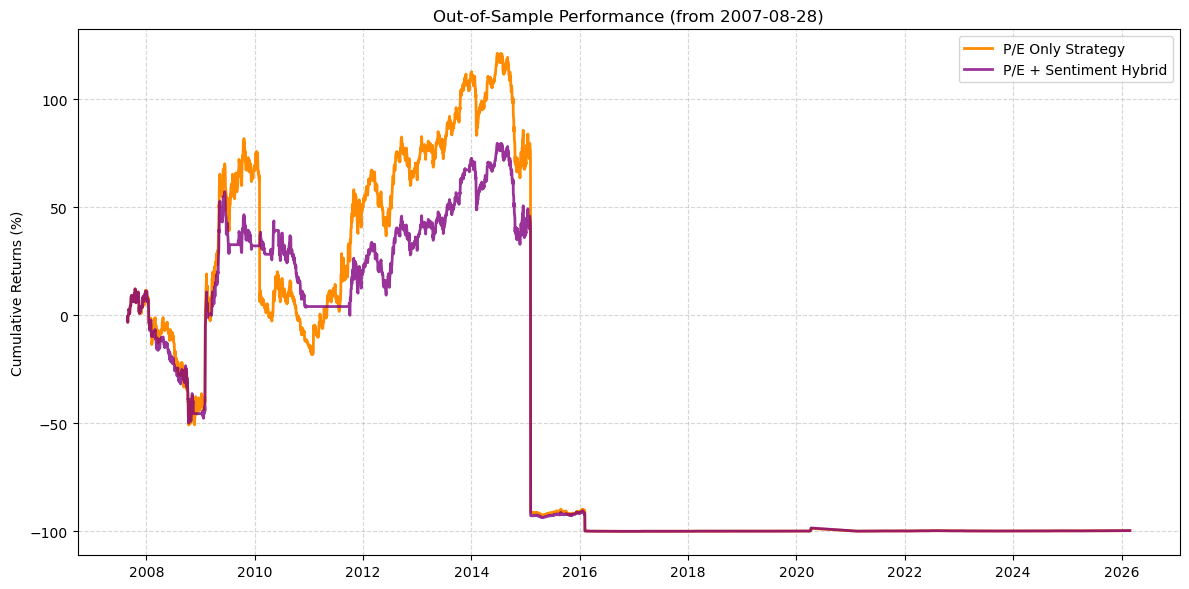

P/E Only Cumulative Return: -99.60%
Hybrid Cumulative Return:   -99.60%
P/E Only Sharpe: 0.22
Hybrid Sharpe:   0.21


In [68]:
test_start = '2007-08-28'
test  = energy_sector.loc[energy_sector.index >= test_start].copy()

# Recalculate cumulative returns from the test start date so the graph starts at 0%
test['cumret_base'] = ((test['base_strat_ret'] + 1).cumprod() - 1) * 100
test['cumret_hybrid'] = ((test['hybrid_strat_ret'] + 1).cumprod() - 1) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(test.index, test['cumret_base'], color='darkorange', lw=2, label='P/E Only Strategy')
ax.plot(test.index, test['cumret_hybrid'], color='purple', lw=2, label='P/E + Sentiment Hybrid', alpha=0.8)
ax.set_title(f'Out-of-Sample Performance (from {test_start})')
ax.set_ylabel('Cumulative Returns (%)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Performance Stats Function
def calc_sharpe(returns):
    if returns.std() == 0: return 0
    return (returns.mean() / returns.std()) * np.sqrt(252)

print(f"P/E Only Cumulative Return: {test['cumret_base'].iloc[-1]:.2f}%")
print(f"Hybrid Cumulative Return:   {test['cumret_hybrid'].iloc[-1]:.2f}%")
print(f"P/E Only Sharpe: {calc_sharpe(test['base_strat_ret']):.2f}")
print(f"Hybrid Sharpe:   {calc_sharpe(test['hybrid_strat_ret']):.2f}")


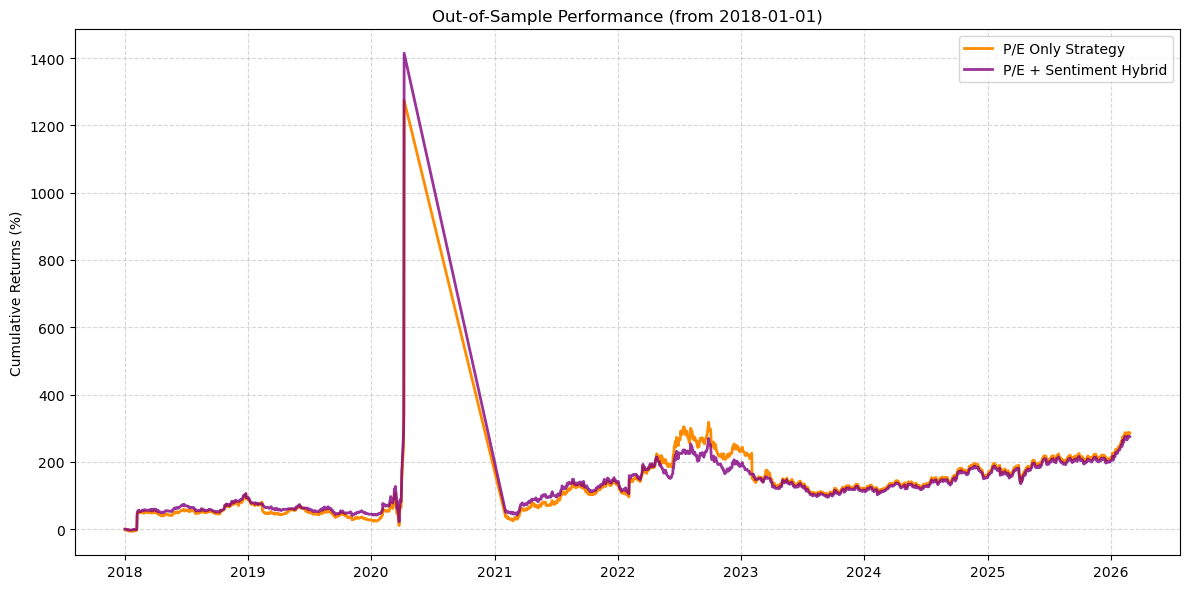

P/E Only Cumulative Return: 285.73%
Hybrid Cumulative Return:   275.00%
P/E Only Sharpe: 0.60
Hybrid Sharpe:   0.60


In [69]:
test_start = '2018-01-01'
test  = energy_sector.loc[energy_sector.index >= test_start].copy()

# Recalculate cumulative returns from the test start date so the graph starts at 0%
test['cumret_base'] = ((test['base_strat_ret'] + 1).cumprod() - 1) * 100
test['cumret_hybrid'] = ((test['hybrid_strat_ret'] + 1).cumprod() - 1) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(test.index, test['cumret_base'], color='darkorange', lw=2, label='P/E Only Strategy')
ax.plot(test.index, test['cumret_hybrid'], color='purple', lw=2, label='P/E + Sentiment Hybrid', alpha=0.8)
ax.set_title(f'Out-of-Sample Performance (from {test_start})')
ax.set_ylabel('Cumulative Returns (%)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Performance Stats Function
def calc_sharpe(returns):
    if returns.std() == 0: return 0
    return (returns.mean() / returns.std()) * np.sqrt(252)

print(f"P/E Only Cumulative Return: {test['cumret_base'].iloc[-1]:.2f}%")
print(f"Hybrid Cumulative Return:   {test['cumret_hybrid'].iloc[-1]:.2f}%")
print(f"P/E Only Sharpe: {calc_sharpe(test['base_strat_ret']):.2f}")
print(f"Hybrid Sharpe:   {calc_sharpe(test['hybrid_strat_ret']):.2f}")
